# Week 6 - Statistical Validation & Predictive Maintenance

Dataset: `pdm_synthetic_features.csv` - sensor readings for 24 pumps across 4 depots, already carrying a
few pre-built rolling features plus the raw signals (vibration, temperature, pressure, acoustic, motor
current) and a health label for each reading.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('pdm_synthetic_features.csv', parse_dates=['timestamp'])
df = df.sort_values(['asset_id', 'timestamp']).reset_index(drop=True)
df.shape, df.head()

((2640, 20),
           timestamp  asset_id  depot  shift  asset_age_months  vibration_g  \
 0  01/01/2026 00:00  PUMP-001  North    Day                15       1.3056   
 1  01/01/2026 06:00  PUMP-001  North  Night                15       1.8329   
 2  01/01/2026 12:00  PUMP-001  North    Day                15       1.7601   
 3  01/01/2026 18:00  PUMP-001  North  Night                15       2.0155   
 4  02/01/2026 00:00  PUMP-001  North    Day                15       1.3916   
 
    temperature_c  pressure_psi  acoustic_db  motor_current_a  error_events  \
 0        64.4815      123.4455      69.9614          34.8057             0   
 1        65.2009      121.4905      70.8481          34.6576             1   
 2        63.9732      123.0420      69.1901          36.7452             0   
 3        63.6278      122.7399      68.1283          36.8624             0   
 4        65.4224      127.2597      71.2493          35.0683             0   
 
    constant_sensor  time_to_failur

## Part 1: Statistical Validation

**Hypothesis:** pumps that are already logged as `Critical` are running with meaningfully higher vibration
than pumps logged `Healthy`. This seems obvious on its face, but "obvious" isn't the same as "statistically
real" - I want to check it properly rather than assume it, since this is the sensor the rest of the notebook
leans on.

- H0 (null): mean vibration is the same for Healthy and Critical pumps
- H1 (alternative): mean vibration is higher for Critical pumps than Healthy pumps

Two independent groups, comparing means -> independent-samples t-test.

In [2]:
df.groupby('health_status')['vibration_g'].agg(['mean', 'std', 'count'])

,mean,std,count
health_status,,,
Critical,4.194609,0.536114,182
Healthy,1.875985,0.485984,2079
Warning,3.081086,0.747927,379


In [3]:
healthy_vib = df.loc[df['health_status'] == 'Healthy', 'vibration_g'].dropna()
critical_vib = df.loc[df['health_status'] == 'Critical', 'vibration_g'].dropna()

t_stat, p_value = stats.ttest_ind(healthy_vib, critical_vib, equal_var=False)
print({'t_statistic': round(t_stat, 3), 'p_value': p_value})

{'t_statistic': np.float64(-56.354), 'p_value': np.float64(6.665464715269511e-128)}


The p-value is far below 0.05 (effectively zero), so I reject the null hypothesis. Healthy and Critical
pumps do not vibrate at the same average level - Critical pumps run noticeably higher. In plain English:
**this isn't random noise, vibration really does climb before a pump is marked Critical**, which is exactly
what a maintenance program would want to be true of a sensor it relies on.

### 95% confidence interval

The t-test tells me the means differ. Now I want a range for how big that difference actually is - a single
average can hide how much readings bounce around.

In [4]:
def mean_ci(series, confidence=0.95):
    series = series.dropna()
    mean = series.mean()
    sem = stats.sem(series)
    lo, hi = stats.t.interval(confidence, len(series) - 1, loc=mean, scale=sem)
    return mean, lo, hi

for label, series in [('Healthy', healthy_vib), ('Critical', critical_vib)]:
    mean, lo, hi = mean_ci(series)
    print(f'{label}: mean={mean:.3f} g, 95% CI=({lo:.3f}, {hi:.3f})')

Healthy: mean=1.876 g, 95% CI=(1.855, 1.897)
Critical: mean=4.195 g, 95% CI=(4.116, 4.273)


/tmp/ipykernel_491/2177048818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['health_status'].isin(['Healthy','Critical'])], x='health_status', y='vibration_g',


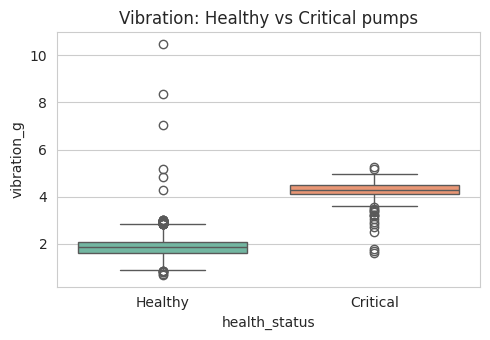

In [5]:
fig, ax = plt.subplots(figsize=(5,3.5))
sns.boxplot(data=df[df['health_status'].isin(['Healthy','Critical'])], x='health_status', y='vibration_g',
            order=['Healthy','Critical'], palette='Set2', ax=ax)
ax.set_title('Vibration: Healthy vs Critical pumps')
plt.tight_layout()
plt.show()

The two confidence intervals don't overlap at all - Healthy sits around 1.9g and Critical sits around
4.2g, each with a fairly tight range around it. That's a second, independent way of seeing the same
conclusion as the t-test: the gap between healthy and failing pumps is both statistically real and large
enough to matter operationally, not just a technicality of a small p-value.

## Part 2: PdM Feature Engineering

Raw sensor readings are noisy on their own - a single vibration reading can spike for reasons that have
nothing to do with the pump actually failing. Rolling features smooth that out and are much better at
showing a *trend* rather than a single reading. I'll build three, using a 6-reading window (this data is
logged every 6 hours, so that's a 36-hour lookback):

In [6]:
work = df.copy()

work['vibration_roll_mean_6'] = work.groupby('asset_id')['vibration_g'].transform(
    lambda s: s.rolling(6, min_periods=1).mean())

work['vibration_rms_6'] = work.groupby('asset_id')['vibration_g'].transform(
    lambda s: np.sqrt(s.pow(2).rolling(6, min_periods=1).mean()))

work['vibration_peak_to_peak_6'] = work.groupby('asset_id')['vibration_g'].transform(
    lambda s: s.rolling(6, min_periods=1).max() - s.rolling(6, min_periods=1).min())

work['pressure_roll_std_6'] = work.groupby('asset_id')['pressure_psi'].transform(
    lambda s: s.rolling(6, min_periods=1).std()).fillna(0)

work[['asset_id','timestamp','vibration_g','vibration_roll_mean_6','vibration_rms_6',
      'vibration_peak_to_peak_6','pressure_roll_std_6']].head(8)

,asset_id,timestamp,vibration_g,vibration_roll_mean_6,vibration_rms_6,vibration_peak_to_peak_6,pressure_roll_std_6
0,PUMP-001,01/01/2026 00:00,1.3056,1.305600,1.305600,0.0000,0.000000
1,PUMP-001,01/01/2026 06:00,1.8329,1.569250,1.591244,0.5273,1.382394
2,PUMP-001,01/01/2026 12:00,1.7601,1.632867,1.649451,0.5273,1.032149
3,PUMP-001,01/01/2026 18:00,2.0155,1.728525,1.748164,0.7099,0.843708
4,PUMP-001,02/01/2026 00:00,1.3916,1.661140,1.682906,0.7099,2.174759
5,PUMP-001,02/01/2026 06:00,1.6969,1.667100,1.685246,0.7099,2.397355
6,PUMP-001,02/01/2026 12:00,1.5453,1.707050,1.718705,0.6239,2.389192
7,PUMP-001,02/01/2026 18:00,1.6593,1.678117,1.689055,0.6239,2.219422


### Visualizing the degradation trend

Numbers in a table don't show a trend the way a chart does. `PUMP-001`'s `fault_type` history shows it
develops a fault partway through the year, so it's a good candidate to check whether these features actually
track degradation over time, or just add noise.

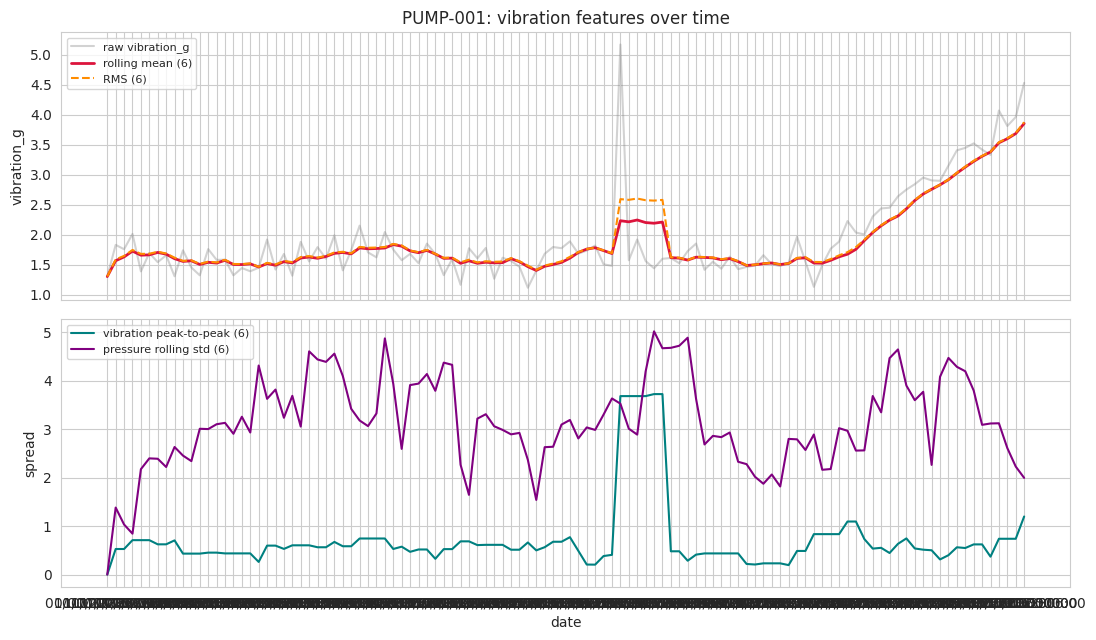

In [7]:
sample = work[work['asset_id'] == 'PUMP-001'].sort_values('timestamp')

fig, axes = plt.subplots(2, 1, figsize=(11,6.5), sharex=True)

axes[0].plot(sample['timestamp'], sample['vibration_g'], alpha=0.35, color='gray', label='raw vibration_g')
axes[0].plot(sample['timestamp'], sample['vibration_roll_mean_6'], color='crimson', linewidth=2, label='rolling mean (6)')
axes[0].plot(sample['timestamp'], sample['vibration_rms_6'], color='darkorange', linewidth=1.5, linestyle='--', label='RMS (6)')
axes[0].set_ylabel('vibration_g')
axes[0].set_title('PUMP-001: vibration features over time')
axes[0].legend(fontsize=8)

axes[1].plot(sample['timestamp'], sample['vibration_peak_to_peak_6'], color='teal', label='vibration peak-to-peak (6)')
axes[1].plot(sample['timestamp'], sample['pressure_roll_std_6'], color='purple', label='pressure rolling std (6)')
axes[1].set_ylabel('spread')
axes[1].set_xlabel('date')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

All four features climb together in the back half of the year, right as the pump heads toward its fault -
the rolling mean and RMS track the rising average, while peak-to-peak and pressure std show the readings
getting less stable at the same time. That's a good sign: the features aren't just repeating each other,
they're picking up two related but different symptoms (rising level, and rising instability).

### Building the target variable

The dataset already has a `health_status` label. I'll turn that into a binary target - `1` if the pump is in
`Warning` or `Critical` state, `0` if `Healthy` - since for a maintenance team the real decision is binary:
does this pump need attention or not.

In [8]:
work['is_failing'] = (work['health_status'] != 'Healthy').astype(int)
work['is_failing'].value_counts(normalize=True).round(3)

is_failing
0    0.788
1    0.212
Name: proportion, dtype: float64

About 21% of readings are flagged as failing in some way. That's an imbalanced but not extreme split -
worth keeping in mind when judging the model below, since a model that just guessed "healthy" every time
would already be right about 79% of the time.

## Part 3: Predictive Modeling

**Model:** logistic regression, predicting `is_failing` from the four engineered features above plus raw
temperature and motor current. Logistic regression rather than linear regression because the target is
binary (failing or not), and I want probabilities I can eventually turn into an alert threshold, not a
continuous number.

In [9]:
features = ['vibration_roll_mean_6','vibration_rms_6','vibration_peak_to_peak_6',
            'pressure_roll_std_6','temperature_c','motor_current_a']

model_df = work[features + ['is_failing']].dropna()
X = model_df[features]
y = model_df['is_failing']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_s, y_train)
pred = clf.predict(X_test_s)

print('accuracy:', round(accuracy_score(y_test, pred), 3))
print()
print(classification_report(y_test, pred, target_names=['Healthy','Failing']))

accuracy: 0.955

              precision    recall  f1-score   support

     Healthy       0.96      0.99      0.97       520
     Failing       0.95      0.83      0.89       140

    accuracy                           0.95       660
   macro avg       0.95      0.91      0.93       660
weighted avg       0.95      0.95      0.95       660



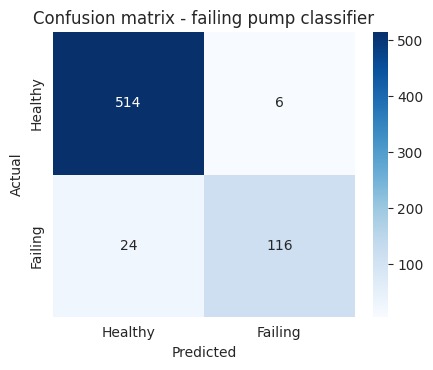

In [10]:
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4.5,3.8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Healthy','Failing'], yticklabels=['Healthy','Failing'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix - failing pump classifier')
plt.tight_layout()
plt.show()

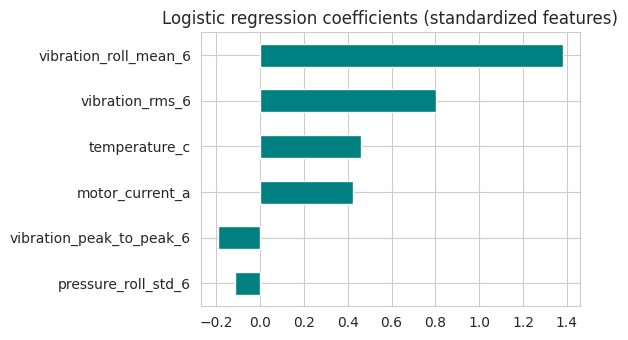

vibration_roll_mean_6       1.381744
vibration_rms_6             0.803549
temperature_c               0.458430
motor_current_a             0.422579
vibration_peak_to_peak_6   -0.192575
pressure_roll_std_6        -0.114430
dtype: float64

In [11]:
coefs = pd.Series(clf.coef_[0], index=features).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(6,3.5))
coefs.plot(kind='barh', ax=ax, color='teal')
ax.invert_yaxis()
ax.set_title('Logistic regression coefficients (standardized features)')
plt.tight_layout()
plt.show()
coefs

### Business implication

The model is 95% accurate overall, but accuracy alone can be misleading on an imbalanced target like this
one, so the confusion matrix matters more:

- **6 false alarms** (healthy pumps flagged as failing) - a wasted maintenance check, mildly annoying but cheap.
- **24 missed failures** (failing pumps the model called healthy) - these are the expensive mistake. A
  missed failure means the pump keeps running until it actually breaks, which is exactly the unplanned
  downtime this whole exercise is trying to prevent.

In other words, the model is good but not good enough to run unsupervised - it catches roughly 83% of
failing pumps (recall for the "Failing" class), which is a solid start but still means about 1 in 6 failing
pumps slips through. The coefficients also line up with what Part 1 and Part 2 already showed: the vibration
features carry the most weight, which matches both the t-test result and the visual trend on PUMP-001. For a
real rollout, this recall rate is the number to keep pushing up before leaning on the model to replace manual
inspection rounds rather than supplement them.